# First model: Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. 

In [40]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from data import utils

## Load Data

In [111]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)

In [112]:
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])

roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

## Feature Selection

In [113]:
eng_features = [
    'Timestamp',
    'in_season', 
    'cumulative_GDD', 
    'Growth_Stage',
    'root_weighted_soil_moisture', 
    'VW_PC1', 
    'VW_PC2', 
    'Shallow_mean',
    'ST_PC1'
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation'
]


X_part1 = eng_non_spectral_df[eng_features]
X_part2 = non_spectral_df[non_spectral_features]
X_non_spectral = pd.merge(X_part2, X_part1, on="Timestamp")


In [114]:
X = utils.merge_with_master(grouped_spectral_df[["Timestamp", "NDVI_mean"]], X_non_spectral)
X = X.drop(columns="Timestamp")
#X = X[X["cumulative_GDD"] > 0].copy()

X_num = X.select_dtypes(include=['number'])
X_cat = X[["Growth_Stage", "in_season"]]
X_cat = pd.get_dummies(X_cat, columns=X_cat.columns, drop_first=True, dtype=int)
X_cat.head()

,Growth_Stage_SoS,Growth_Stage_V12,Growth_Stage_V13,Growth_Stage_V16+,Growth_Stage_V2,Growth_Stage_V4,Growth_Stage_V6,Growth_Stage_V8-V9,Growth_Stage_VE,Growth_Stage_VT,in_season_1
0,0,0,0,0,0,0,0,0,1,0,1
1,0,0,1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,0,0,0,1,1
4,0,0,0,0,0,0,0,0,0,1,1


## Training Model

In [116]:
scaler = StandardScaler()

X_num_scaled = scaler.fit_transform(X_num)
X_scaled_num_df = pd.DataFrame(X_num_scaled, columns=X_num.columns, index=X_num.index)

X_scaled = pd.concat([X_scaled_num_df, X_cat], axis=1)
X_scaled

,NDVI_mean,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,in_season,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,VW_PC2,Shallow_mean,ST_PC1,Growth_Stage_SoS,Growth_Stage_V12,Growth_Stage_V13,Growth_Stage_V16+,Growth_Stage_V2,Growth_Stage_V4,Growth_Stage_V6,Growth_Stage_V8-V9,Growth_Stage_VE,Growth_Stage_VT,in_season_1
0,0.898028,1.769453,1.609369,1.923677,1.951094,-0.219839,0.897070,-0.829791,0.700860,-0.573904,-0.916818,1.612942,1.595932,0,0,0,0,0,0,0,0,1,0,1
1,2.093782,1.143998,0.943155,1.097380,0.997917,2.322768,0.897070,-0.103047,0.594564,-0.865634,-0.880003,1.420729,1.426161,0,0,1,0,0,0,0,0,0,0,1
2,0.052940,-1.064289,-0.982647,-1.282293,-1.054327,-0.219839,0.897070,0.479298,0.893140,0.221296,-1.242510,-0.804356,-0.785376,0,0,0,0,0,0,0,0,0,1,1
3,-0.225771,-1.255715,-1.165525,-1.210530,-1.148105,-0.219839,0.897070,0.479381,0.831235,-0.050188,-0.963862,-1.129397,-1.108518,0,0,0,0,0,0,0,0,0,1,1
4,-0.391114,-1.045889,-0.636246,-1.160388,-1.248290,-0.219839,0.897070,0.479390,0.786322,-0.249295,-0.782880,-1.061346,-1.059310,0,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,-0.298266,-0.277050,-0.491965,-0.087737,0.689321,-0.219839,-1.114741,-0.925268,-1.065467,-0.104840,2.248359,0.024830,0.020483,0,0,0,0,0,0,0,0,0,0,0
301,-0.288391,0.815002,1.105743,0.660774,0.549209,-0.219839,-1.114741,-0.925268,-1.065467,-0.053120,2.102226,0.488271,0.450938,0,0,0,0,0,0,0,0,0,0,0
302,-0.120206,0.167688,0.044726,0.133785,0.887368,-0.219839,-1.114741,-0.925268,-1.065467,1.771420,0.510429,-0.075971,-0.093930,0,0,0,0,0,0,0,0,0,0,0
303,0.175139,0.074358,-0.260121,0.185015,1.306830,-0.080617,-1.114741,-0.925268,-1.065467,1.540424,0.701562,-0.046141,-0.058787,0,0,0,0,0,0,0,0,0,0,0


In [117]:
bics = []
components = range(1, 12)
for k in components:
    gmm = GaussianMixture(n_components=k, covariance_type='full')
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))


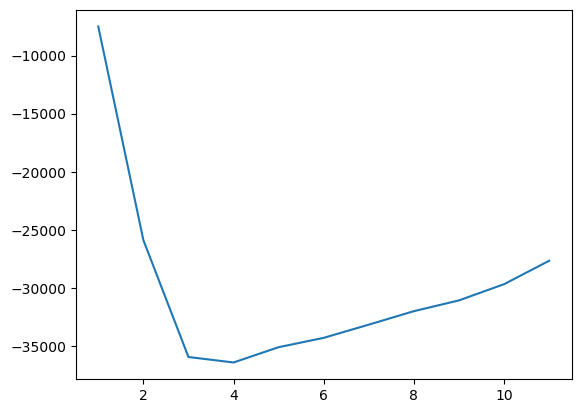

In [118]:
plt.plot(components, bics)